In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries loaded!")

Libraries loaded!


In [3]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape


(1025, 14)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.groupby('target')[['age', 'chol', 'thalach']].mean()

,age,chol,thalach
target,,,
0,56.569138,251.292585,139.130261
1,52.408745,240.979087,158.585551


In [8]:
df.groupby('target')['age'].describe()


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,499.0,56.569138,7.908153,35.0,52.0,58.0,62.0,77.0
1,526.0,52.408745,9.631804,29.0,44.0,52.0,59.0,76.0


# Heart Disease Distribution

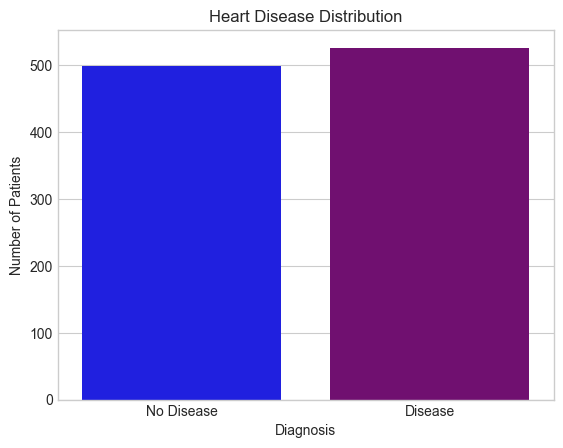

In [9]:
sns.countplot(x='target', data=df,
              palette={0: 'blue', 1: 'purple'},
              hue='target', legend=False)
plt.title('Heart Disease Distribution')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

#Chart 2: Age Distribution by Outcome

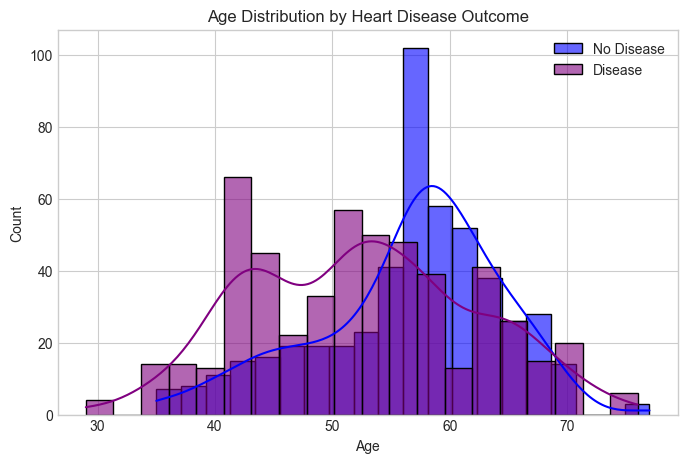

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data=df[df['target']==0], x='age', bins=20, kde=True,
             color='blue', label='No Disease', alpha=0.6)
sns.histplot(data=df[df['target']==1], x='age', bins=20, kde=True,
             color='purple', label='Disease', alpha=0.6)

plt.title('Age Distribution by Heart Disease Outcome')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

Stats said average age with disease = 52
Chart shows disease peaks visually around 58

# Chart 3: Cholesterol vs Max Heart Rate


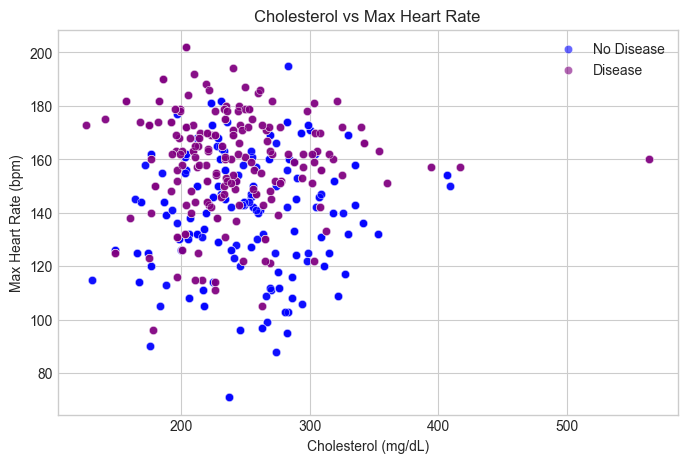

In [12]:
plt.figure(figsize=(8,5))

# Plot each group separately with specific colors
sns.scatterplot(data=df[df['target']==0], x='chol', y='thalach', 
                color='blue', label='No Disease', alpha=0.6)
sns.scatterplot(data=df[df['target']==1], x='chol', y='thalach', 
                color='purple', label='Disease', alpha=0.6)

plt.title('Cholesterol vs Max Heart Rate')
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Max Heart Rate (bpm)')
plt.legend()
plt.show()

From this chart, this confirms that patients with heart disease have:
- Lower cholesterol (counterintuitive but consistent!)
- Higher max heart rate

In [13]:
print("Total patients:", df.shape[0])
print("No Disease patients:", df[df['target']==0].shape[0])
print("Disease patients:", df[df['target']==1].shape[0])

Total patients: 1025
No Disease patients: 499
Disease patients: 526


Chart 4: Correlation Heatmap

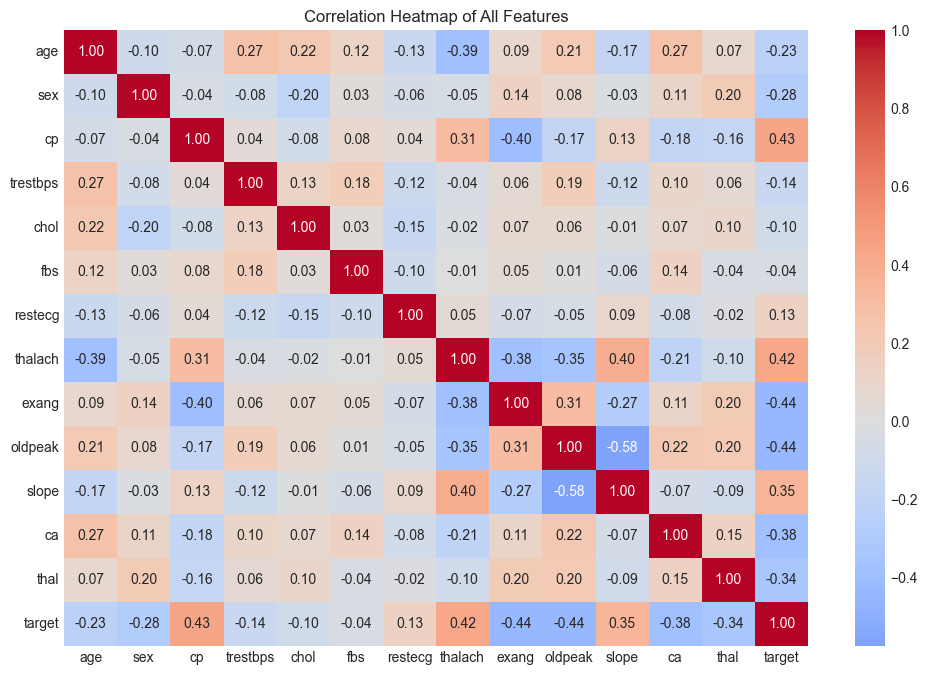

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap of All Features')
plt.show()

In [15]:
df.corr()['target'].sort_values(ascending=False)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

Findings from heat map:
cp (chest pain) → positively correlated with disease. More chest pain = more likely disease.
thalach (max heart rate) → positively correlated. 
ca, exang, oldpeak → negatively correlated. As these increase, disease likelihood decreases


# Chart 5: Chest Pain Type vs Disease

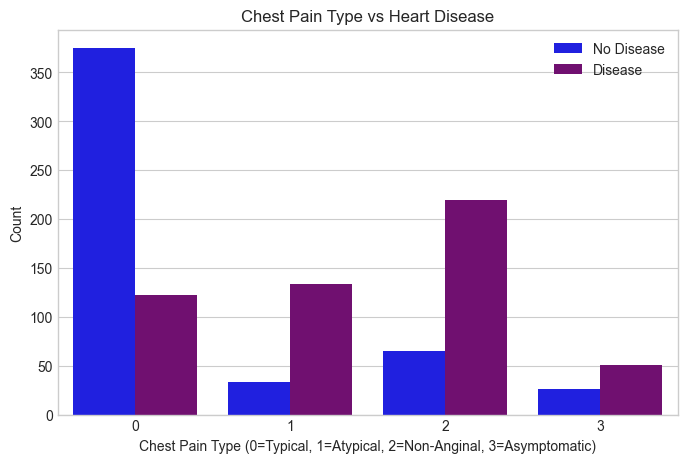

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='cp', data=df, 
              hue='target',
              palette={0: 'blue', 1: 'purple'})
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0=Typical, 1=Atypical, 2=Non-Anginal, 3=Asymptomatic)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'])
plt.show()

Typical angina doesn't necessarily mean heart disease. Patients with heart disease actually present more with non-anginal and atypical chest pain, which is why heart disease is often missed or misdiagnosed in real life. Doctors can't rely on chest pain type alone. 

## Heart Disease Analysis: Key Findings

### Dataset
- 1025 patients, 14 variables, no missing values
- 51% of patients have heart disease (balanced dataset)

### Key Findings
1. FIndings about age
Average age was 54, but disease peaked visually around 58, suggesting middle-to-late age carries higher risk.

2. Findings about cholesterol
Average cholesterol was 246 mg/dL, which is borderline high (normal is under 200), yet paradoxically patients WITHOUT disease had higher cholesterol, suggesting cholesterol alone is a poor predictor.

3. Findings about chest pain
Chest pain is positively correlated with heart disease. More chest pain = higher likelihood of having heart disease.

4. Findings about thalach and cp correlation
thalach (max heart rate) is positively correlated with heart disease.

### Surprising Findings
1. Patients with no heart disease have higher cholesterol. Cholesterol alone doesn't tell entire story. This means heart disease is caused by a combination of factors, age, blood pressure, cholesterol and lifestyle, not simply cholesterol alone. Thus, it is important to multivariate analysis (look at many variables together) instead of just one at a time.
2. Typical angina patients had LESS disease than expected.

### Limitations
- Data set dates from 1988 and consists of four databases from Cleveland, Hungary, Switzerland, and Long Beach V. This means that Southeast Asians are not included in the dataset, limiting the dataset.

### Conclusion
- If a doctor could only use 2 variables to predict heart disease from this dataset, I would recommend using chest pain and thalach (max heart rate) because they are most strongly correlated with target. Future analysis could build a machine learning model using these features to predict disease risk.

In [ ]:
# Save all charts as images
import os
os.makedirs('charts', exist_ok=True)